# 1) Chargement des données

Allez, cadeau 😘:

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "..\\Data\\raw\\billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")

    # Création de la variable is_fake qui est l'inverse de is_genuine pour que 1 (Tgrue) devienne l'alerte du faux billet
    df['is_fake'] = ~df['is_genuine']

    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 8)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_fake
0,True,171.81,104.86,104.95,4.52,2.89,112.83,False
1,True,171.46,103.36,103.66,3.77,2.99,113.09,False
2,True,172.69,104.48,103.50,4.40,2.94,113.16,False
3,True,171.36,103.91,103.94,3.62,3.01,113.51,False
4,True,171.73,104.28,103.46,4.04,3.48,112.54,False


# 2) Analyse exploratoire (EDA)

Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

In [40]:
print("Types des données :")
print(df.dtypes)
print(f"Dimension du dataset : {df.shape}")

Types des données :
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
is_fake            bool
dtype: object
Dimension du dataset : (1500, 8)


In [41]:
# Description des données stat des variables
print("Description statistiques :")
display(df.describe())

Description statistiques :


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [42]:
# Vérification des éventuels null
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
is_fake          0
dtype: int64


In [43]:
# Répartition de la colonne is_fake (la cible)
print("Distribution de 'is_fake'")
faux = df['is_fake'].value_counts()
print(faux)

Distribution de 'is_fake'
is_fake
False    1000
True      500
Name: count, dtype: int64


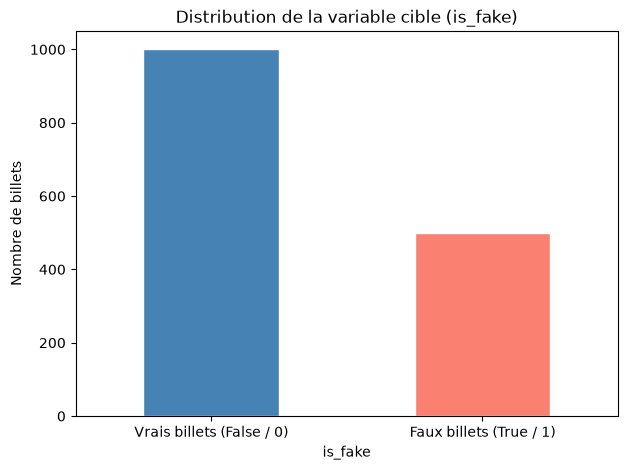

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
faux.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
ax.set_xticklabels(['Vrais billets (False / 0)', 'Faux billets (True / 1)'], rotation=0)
ax.set_title("Distribution de la variable cible (is_fake)")
ax.set_ylabel("Nombre de billets")
plt.show()

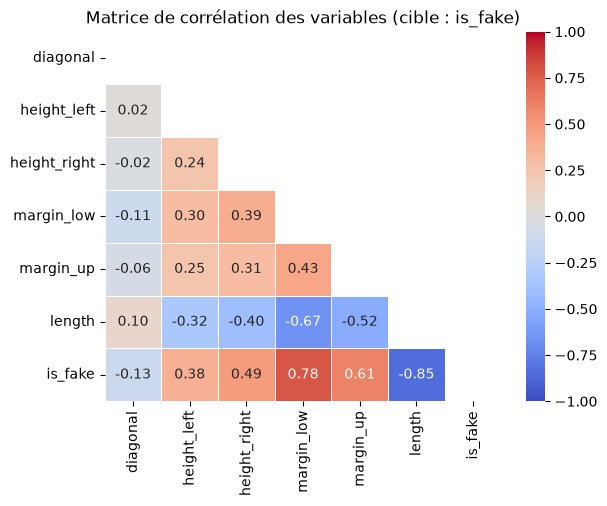

In [45]:
# Conversion is_fake en int : True(faux billet = 1), False(vrai billet = 0)
df_numerique = df.drop(columns=['is_genuine']).copy()
df_numerique['is_fake'] = df_numerique['is_fake'].astype(int)

# Vérification des variables corrélées à is_fake
corr_matrix = df_numerique.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5
)
plt.title("Matrice de corrélation des variables (cible : is_fake)")
plt.show()


Les variables les plus corrélées à is_fake (faux billet = 1) sont :
* la longueur (-0.85) : plus la longueur est faible, plus le risque de faux billet augmente
* la marge du bas (0.78) : plus la marge du bas est élevée, plus le risque de faux billet augmente
* la marge du haut (0.61) : plus la marge du haut est élevée, plus le risque de faux billet augmente

Note : les signes sont inversés par rapport à is_genuine — la relation physique est identique,
seule la convention de la cible a changé (on cherche maintenant le danger, pas l'authenticité).

* Cela signifie que ces variables seront celles ayant le plus de poids dans mon modèle


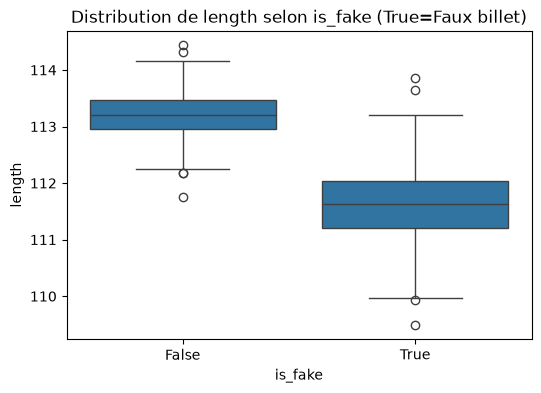

In [46]:
# Boxplot de la distribution des billets selon la longueur
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='is_fake', y='length')
plt.title("Distribution de length selon is_fake (True=Faux billet)")
plt.xlabel("is_fake")
plt.show()

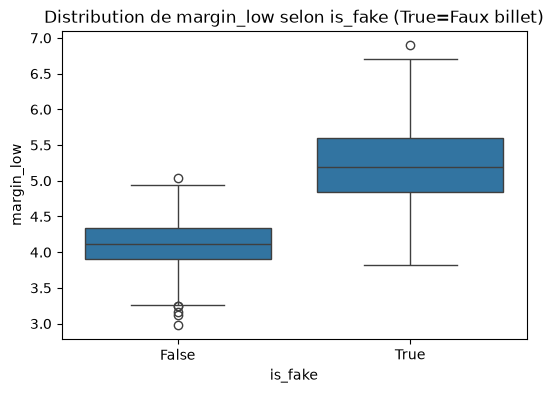

In [47]:
# Boxplot de la distribution des billets selon la marge inférieure
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='is_fake', y='margin_low')
plt.title("Distribution de margin_low selon is_fake (True=Faux billet)")
plt.xlabel("is_fake")
plt.show()

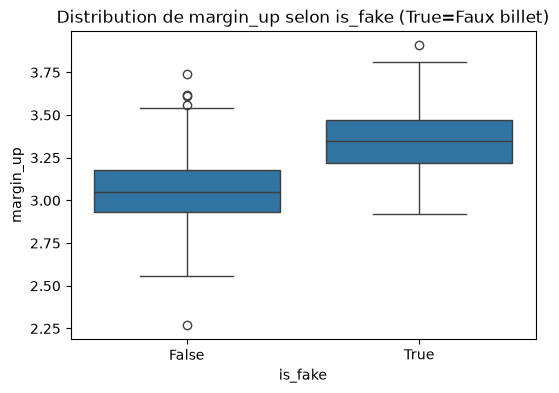

In [48]:
# Boxplot de la distribution des billets selon la marge supérieure
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='is_fake', y='margin_up')
plt.title("Distribution de margin_up selon is_fake (True=Faux billet)")
plt.xlabel("is_fake")
plt.show()

Les boxplots confirment la corrélation entre l'authenticité du billet et la longueur ou encore la marge du bas (et plus légèrement haut)

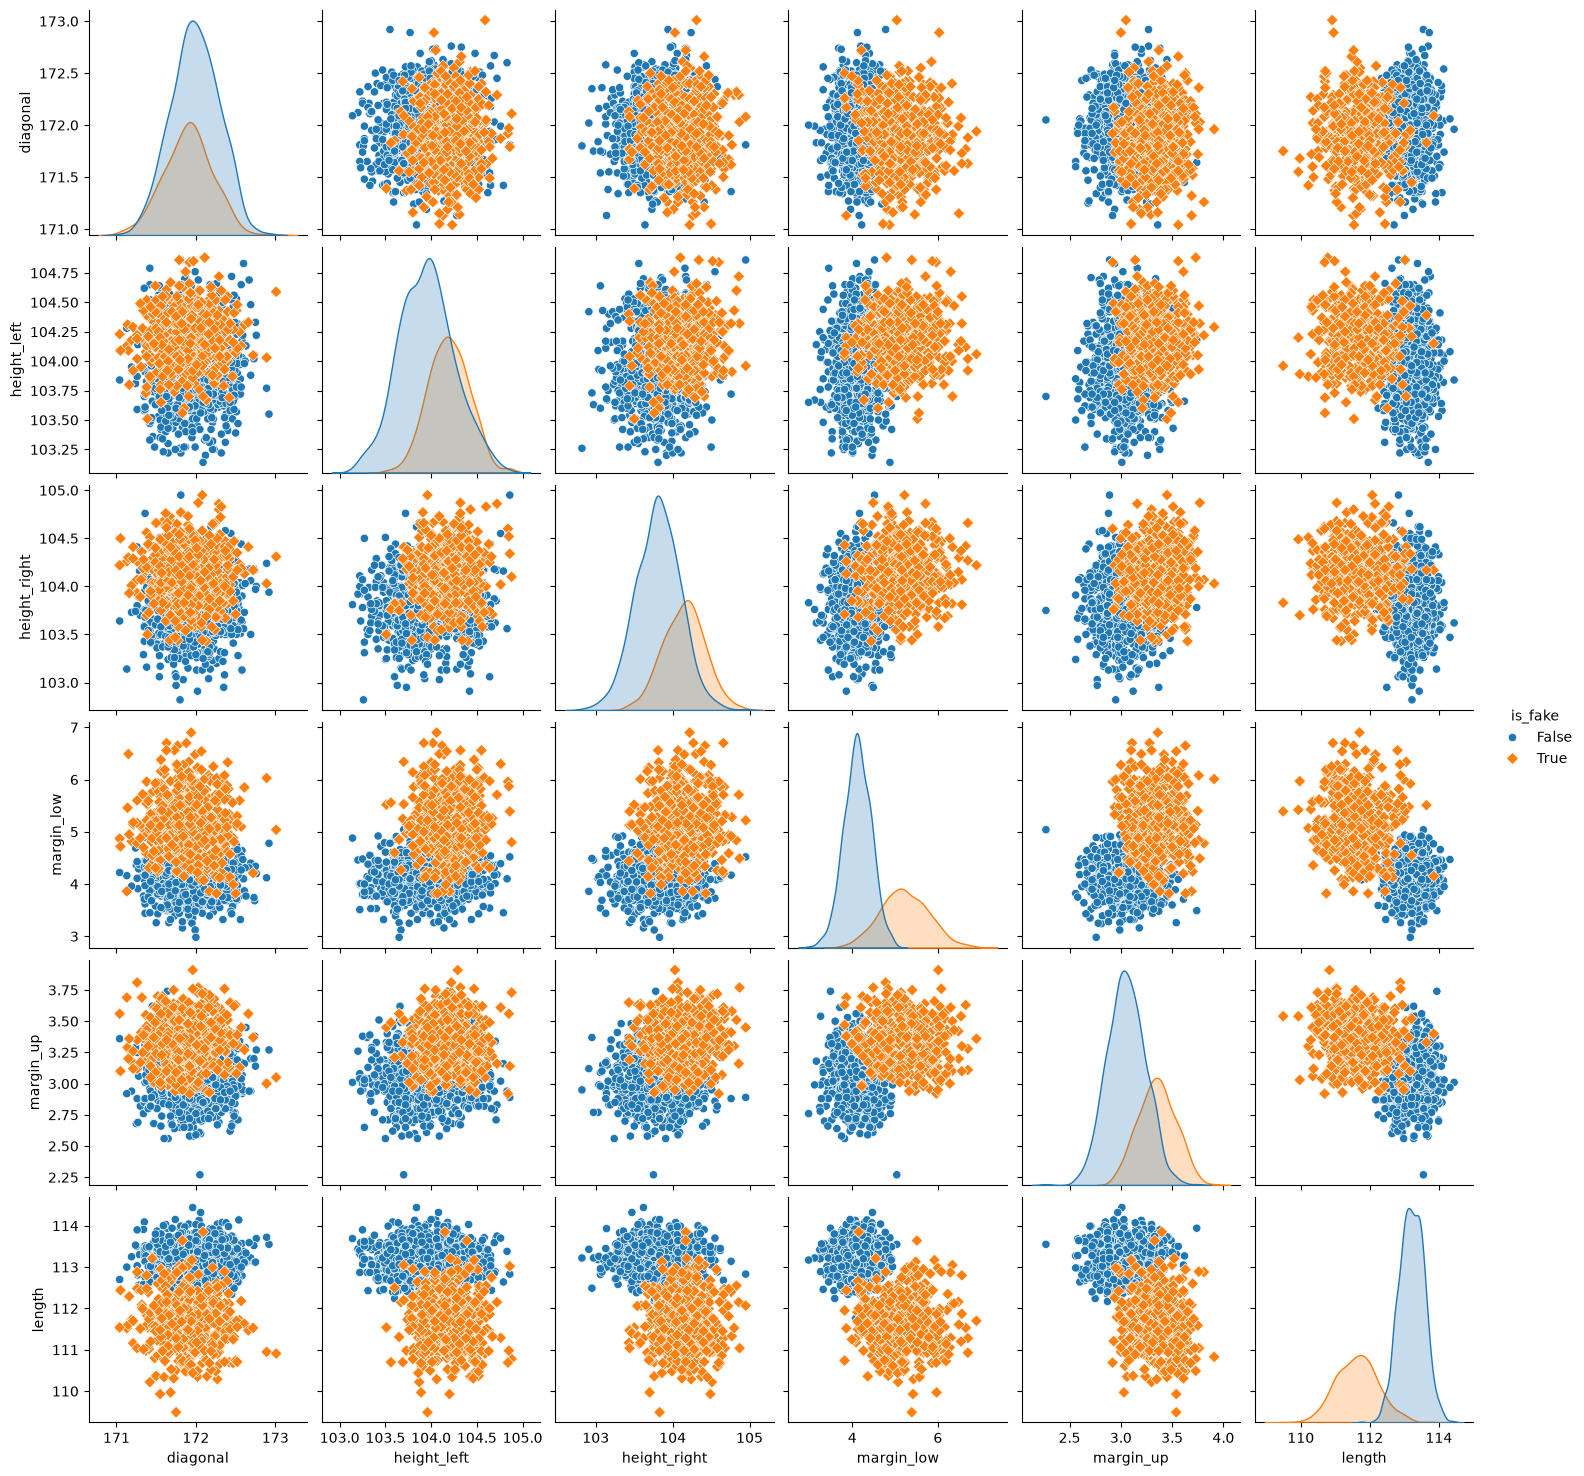

In [49]:
# Et suppression de la colonne is_geniune
df = df.drop(columns=['is_genuine'])
sns.pairplot(data=df,hue='is_fake', markers=["o", "D"])

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.

D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l'étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

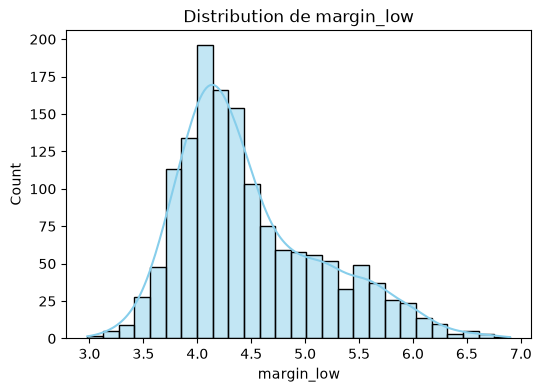

In [50]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='margin_low', kde=True, color='skyblue')
plt.title("Distribution de margin_low")
plt.show()

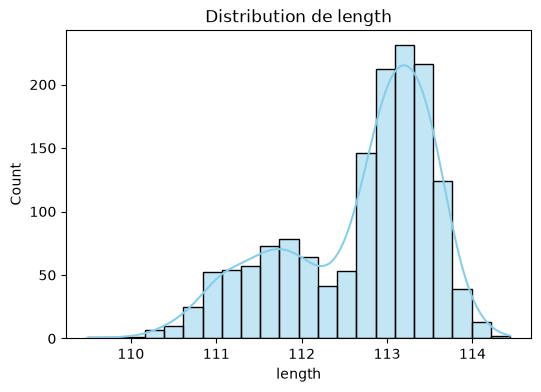

In [51]:
#  Distribution de length : utile du fait de la corrélation importante avec is_geniune
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='length', kde=True, color='skyblue')
plt.title("Distribution de length")
plt.show()

#### En cas d'imputation par la moyenne ou la médiane : 
* Il est important de préciser une notion essentielle en data sciences : pour éviter la Data Leakage (fuite de données), on calcule la médiane (si outliers) ou moyenne (distribution normale) sur les données d'entrainement uniquement mais on l'utilise ensuite pour compléter l'ensemble des valeurs
#### Au vue de la distribution, les actions seraient :
* Margin_low : Distribution asymétrique ==> imputation par la médiane
* Ici les données manquantes correspondent à 37 réparties comme suit : 8 faux billets et 29 vrais ==> A 2.5% de valeurs manquantes, la suppression est acceptable

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Séparation X / y 
# Et suppression des colonnes cibles 
y = df['is_fake']
X = df.drop(columns=['is_fake'])

# Vérification des dimensions des jeux de données
print("X shape :", X.shape)
print("y shape :", y.shape)

# Séparation à 80/20 avec une stratification sur y (pour que la sous/sur représentation n'impacte pas les résultats)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputation par la médiane ( avec le fit sur X_train uniquement) 
# strategy='median' : robuste aux outliers (distribution asymétrique de margin_low)
imputer = SimpleImputer(strategy='median')
# fit_transform sur train : calcule la médiane à partir du train uniquement pour éviter de polluer le test
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X shape : (1500, 6)
y shape : (1500,)


### Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu'il n'a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d'échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d'importance.

In [53]:
from sklearn.preprocessing import StandardScaler

# Initialisation du Scaler
scaler = StandardScaler()

# Centrer et réduire
# fit_transform sur X_train_imp --> calcule moyenne/écart-type sur le train imputé uniquement
# transform sur X_test_imp --> applique les paramètres sans recalculer
X_train_scale = scaler.fit_transform(X_train_imp)
X_test_scale  = scaler.transform(X_test_imp)

print(f"X_train_scale : {X_train_scale.mean():.4f}, std {X_train_scale.std():.4f}")


X_train_scale : -0.0000, std 1.0000


## PCA

In [88]:
from sklearn.decomposition import PCA

# Sélection des variables géométriques (on exclut 'is_genuine' s'il est présent)
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]
X = df[features]

# On récupère les valeurs 'is_fake' sous forme de Series Pandas
y = df["is_fake"]

# Application de l'ACP
pca = PCA(n_components=X.shape[1])
X_projected = pca.fit_transform(X_train_scale)

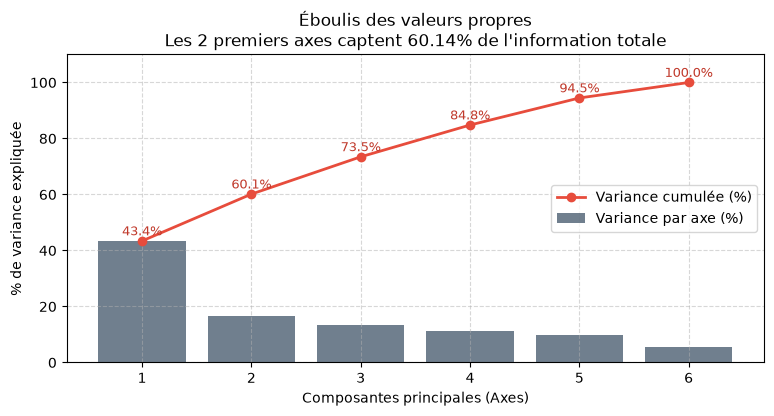

In [91]:
# Calcul des variances cumulées
variance_individuelle = pca.explained_variance_ratio_ * 100
variance_cumulee = np.cumsum(variance_individuelle)

# Eboulis des valeurs propres
plt.figure(figsize=(9, 4))

# Barres pour l'apport de chaque axe
plt.bar(
    range(1, len(features) + 1),
    variance_individuelle,
    alpha=0.7,
    label="Variance par axe (%)",
    color="#34495e",
)

# Ligne rouge pour le cumul de l'information
plt.plot(
    range(1, len(features) + 1),
    variance_cumulee,
    c="#e74c3c",
    marker="o",
    linewidth=2,
    label="Variance cumulée (%)",
)
for i, val in enumerate(variance_cumulee):
    plt.text(i + 1, val + 2, f"{val:.1f}%", ha="center", fontsize=9, color="#c0392b")

plt.xlabel("Composantes principales (Axes)")
plt.ylabel("% de variance expliquée")
plt.title(
    f"Éboulis des valeurs propres\nLes 2 premiers axes captent {variance_cumulee[1]:.2f}% de l'information totale"
)
plt.ylim(0, 110)
plt.legend(loc="center right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

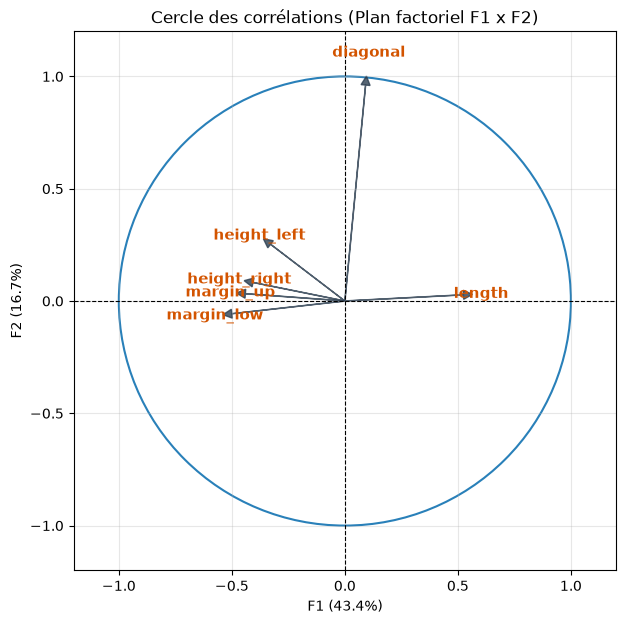

In [94]:
# CERCLE DES CORRÉLATIONS (F1, F2)

pcs = pca.components_

plt.figure(figsize=(7, 7))

# Dessin du cercle unité (rayon = 1)
circle = plt.Circle((0, 0), 1, facecolor="none", edgecolor="#2980b9", linestyle="-", linewidth=1.5)
plt.gca().add_artist(circle)

# Tracé des flèches pour chaque variable géométrique
for i, var in enumerate(features):
    x_arrow = pcs[0, i]
    y_arrow = pcs[1, i]

    # Dessin de la flèche
    plt.arrow(
        0,
        0,
        x_arrow,
        y_arrow,
        head_width=0.04,
        head_length=0.04,
        color="#2c3e50",
        alpha=0.8,
    )

    # Positionnement du texte de la variable légèrement décalé de la flèche
    plt.text(
        x_arrow * 1.15,
        y_arrow * 1.15,
        var,
        color="#d35400",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
    )

# Configuration des axes géométriques du cercle
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.xlabel(f"F1 ({variance_individuelle[0]:.1f}%)")
plt.ylabel(f"F2 ({variance_individuelle[1]:.1f}%)")
plt.title("Cercle des corrélations (Plan factoriel F1 x F2)")
plt.grid(True, alpha=0.3)
plt.show()


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

#### Regression logistique

In [ ]:
#  Entrainement du modèle 
from sklearn.linear_model import LogisticRegression

model_rl = LogisticRegression(random_state=42, max_iter=1000)
model_rl.fit(X_train_scale, y_train)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Prédiction sur le test
y_pred_rl = model_rl.predict(X_test_scale)

print("--- Rapport Régression Logistique ---")
print(classification_report(y_test, y_pred_rl, 
                            labels=[0, 1], 
                            target_names=["Vrai billet", "Faux billet"]))

--- Rapport Régression Logistique ---
              precision    recall  f1-score   support

 Vrai billet       0.99      1.00      0.99       200
 Faux billet       1.00      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



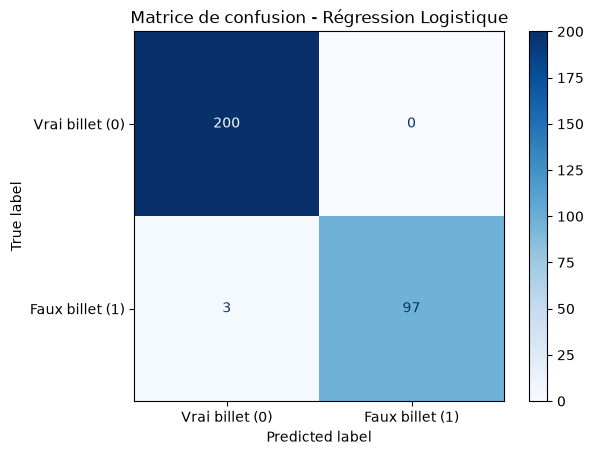

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cmrl = confusion_matrix(y_test, y_pred_rl)
disprl = ConfusionMatrixDisplay(confusion_matrix=cmrl, 
                                display_labels=["Vrai billet (0)", "Faux billet (1)"])
disprl.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - Régression Logistique")
plt.show()


#### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scale, y_train)

y_pred_knn = model_knn.predict(X_test_scale)

print("--- Rapport KNN ---")
print(classification_report(y_test, y_pred_knn, 
                            labels=[0, 1],
                            target_names=["Vrai billet", "Faux billet"]))


--- Rapport KNN ---
              precision    recall  f1-score   support

 Vrai billet       0.99      1.00      0.99       200
 Faux billet       1.00      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



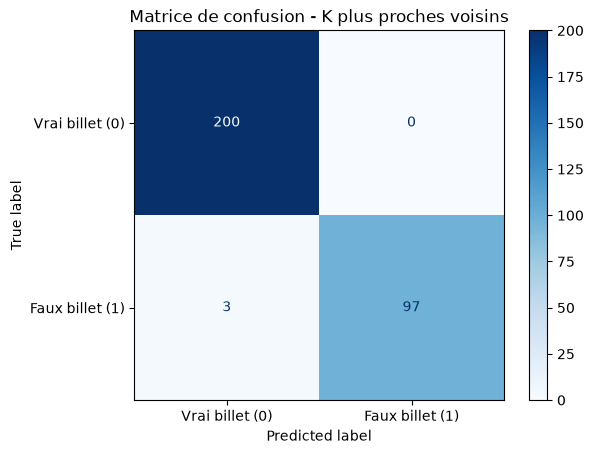

In [ ]:
cmknn = confusion_matrix(y_test, y_pred_knn)
dispknn = ConfusionMatrixDisplay(confusion_matrix=cmknn,
                                display_labels=["Vrai billet (0)", "Faux billet (1)"])
dispknn.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - K plus proches voisins")
plt.show()


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scale, y_train)

y_pred_rf = model_rf.predict(X_test_scale)

print("--- Rapport Random Forest ---")
print(classification_report(y_test, y_pred_rf, 
                            labels=[0, 1],
                            target_names=["Vrai billet", "Faux billet"]))


--- Rapport Random Forest ---
              precision    recall  f1-score   support

 Vrai billet       0.99      1.00      0.99       200
 Faux billet       1.00      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



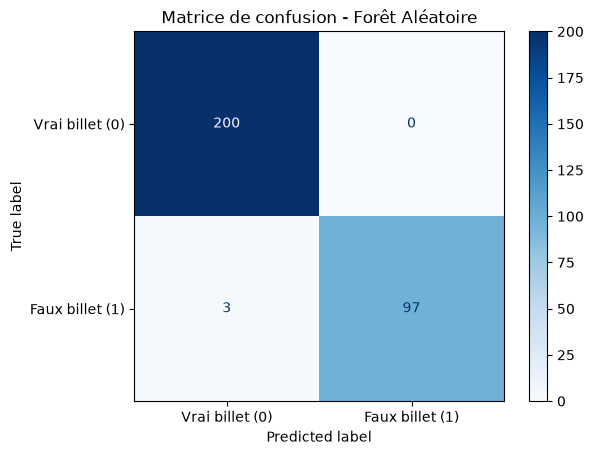

In [ ]:
cmrf = confusion_matrix(y_test, y_pred_rf)
disprf = ConfusionMatrixDisplay(confusion_matrix=cmrf,
                                display_labels=["Vrai billet (0)", "Faux billet (1)"])
disprf.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - Forêt Aléatoire")
plt.show()


### K MEANS

In [ ]:
# Confirmation du nombre de clusters avec le score de silhouette
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

k_list = list(range(2, 7))
scores_silhouette = []

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_test = kmeans.fit_predict(X_train_scale)
    score = silhouette_score(X_train_scale, labels_test)
    scores_silhouette.append(score)
    print(f"Pour K = {k}, le score de Silhouette est de : {score:.3f}")

fig_silh = px.line(
    x=k_list, 
    y=scores_silhouette,
    title="Évolution du score de Silhouette",
    labels={'x': 'Nombre de clusters (K)', 
            'y': 'Score de Silhouette'})
fig_silh.update_layout(
    template="plotly_white")
fig_silh.show()

Pour K = 2, le score de Silhouette est de : 0.343
Pour K = 3, le score de Silhouette est de : 0.208
Pour K = 4, le score de Silhouette est de : 0.158
Pour K = 5, le score de Silhouette est de : 0.149
Pour K = 6, le score de Silhouette est de : 0.152


In [ ]:
# Entraînement du K-Means avec 2 clusters
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init="auto")
cluster_train_labels = kmeans_final.fit_predict(X_train_scale)


In [ ]:
# Ajout des clusters au dataframe d'origine pour analyse
X_train_copy = X_train.copy()
X_train_copy["cluster"] = cluster_train_labels

# Affichage des valeurs moyennes de chaque groupe
print(X_train_copy.groupby('cluster').mean().round(2))

         diagonal  height_left  height_right  margin_low  margin_up  length
cluster                                                                    
0          171.90       104.20        104.16        5.20       3.35  111.63
1          171.99       103.94        103.81        4.11       3.05  113.19


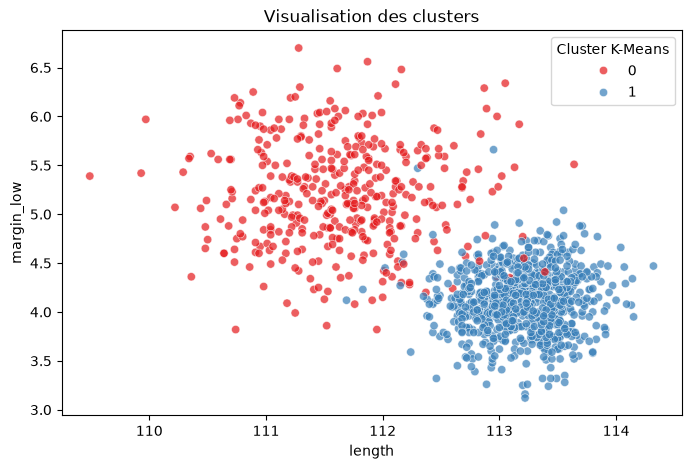

In [ ]:
# FORME DES CLUSTERS avec deux variables importantes (length et margin_low) 
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=X_train_copy, 
    x='length', 
    y='margin_low', 
    hue='cluster', 
    palette='Set1', 
    alpha=0.7
)
plt.title("Visualisation des clusters")
plt.legend(title="Cluster K-Means")
plt.show()

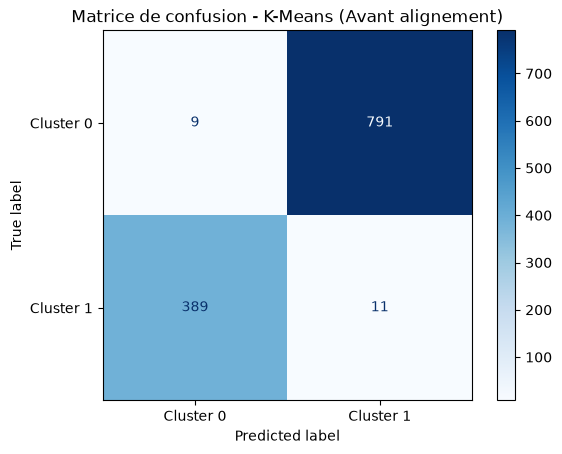

In [ ]:
#  MATRICE DE CONFUSION KMEANS
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_kmeans = confusion_matrix(y_train, cluster_train_labels)

disp_kmeans = ConfusionMatrixDisplay(
    confusion_matrix=cm_kmeans,
    display_labels=["Cluster 0", "Cluster 1"]
)

disp_kmeans.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - K-Means (Avant alignement)")
plt.show()

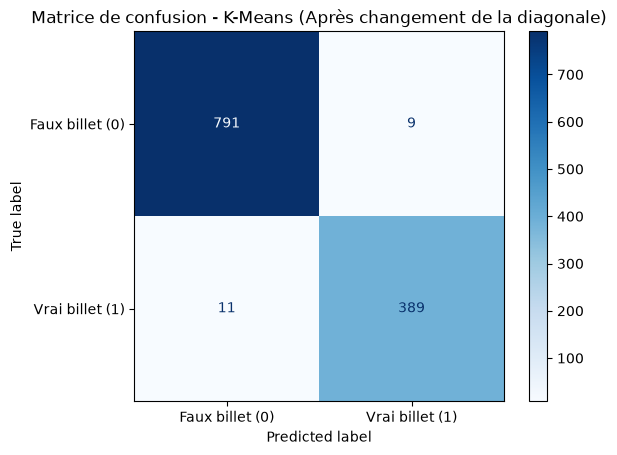

In [ ]:
# Inversion des labels 

X_train_copy["cluster_corrige"] = X_train_copy["cluster"].map({0: 1, 1: 0})

cm_kmeans_apres = confusion_matrix(y_train, X_train_copy["cluster_corrige"])

disp_kmeans_apres = ConfusionMatrixDisplay(
    confusion_matrix=cm_kmeans_apres,
    display_labels=["Faux billet (0)", "Vrai billet (1)"]
)

disp_kmeans_apres.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - K-Means (Après changement de la diagonale)")
plt.show()

#### Si on reprend les info précédentes, la conclusion selon la médiane : 
* les faux billets sont moins longs que les vrais
* les faux billets ont des marges du bas plus grandes que les vrais
* les faux billets ont des marges du haut un peu plus grandes que les vrais

#### Donc les clusters sont les suivantes : 
* 0 = False = Faux billets
* 1 = True = Vrais billets

In [ ]:
# Prédiction sur le jeu de test
y_pred_kmeans = kmeans_final.predict(X_test_scale)

cmkmeans = confusion_matrix(y_test, y_pred_kmeans)


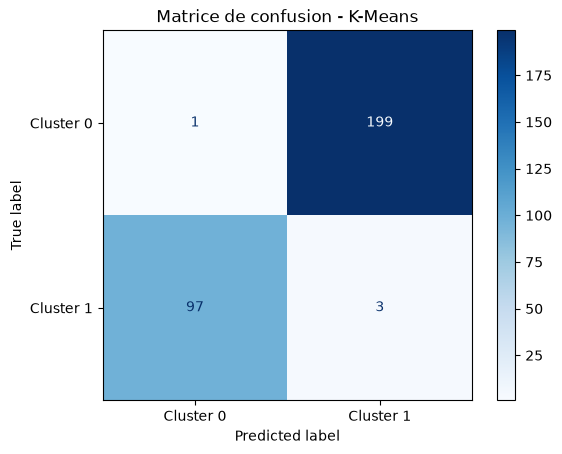

In [ ]:
dispersionkmeans = ConfusionMatrixDisplay(confusion_matrix=cmkmeans,
                                        display_labels=["Cluster 0", "Cluster 1"])
dispersionkmeans.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - K-Means")
plt.show()


# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

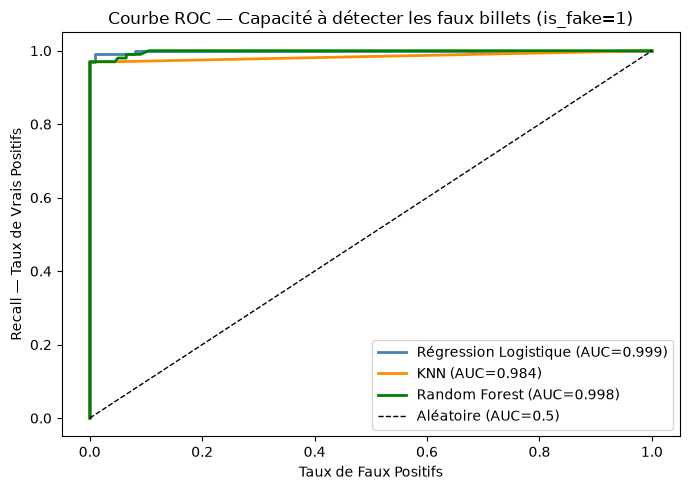

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# predict_proba[:, 1] --> probabilité d'être un FAUX billet (classe 1 = is_fake)
y_probs_rl  = model_rl.predict_proba(X_test_scale)[:, 1]
y_probs_knn = model_knn.predict_proba(X_test_scale)[:, 1]
y_probs_rf  = model_rf.predict_proba(X_test_scale)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))

for nom, y_probs, color in [
    ("Régression Logistique", y_probs_rl,  "steelblue"),
    ("KNN", y_probs_knn, "darkorange"),
    ("Random Forest", y_probs_rf,  "green"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_probs, pos_label=1)  
    auc = roc_auc_score(y_test, y_probs)
    ax.plot(fpr, tpr, label=f"{nom} (AUC={auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Aléatoire (AUC=0.5)")
ax.set_xlabel("Taux de Faux Positifs")
ax.set_ylabel("Recall — Taux de Vrais Positifs")
ax.set_title("Courbe ROC — Capacité à détecter les faux billets (is_fake=1)")
ax.legend()
plt.tight_layout()
plt.show()

# Plus l'AUC est proche de 1, meilleure est la détection des faux billets.


# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [ ]:
# Création du Pipeline

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import joblib

pipeline_final = make_pipeline(
    # Pour traiter les Null avant la mise à l'échelle
    SimpleImputer(strategy='median'),   
    # Centrer et Réduire
    StandardScaler(),
    # Régression logistique
    LogisticRegression(random_state=42, max_iter=500)
)

pipeline_final.fit(X_train, y_train)

# joblib.dump(pipeline_final, "modele_prediction_billets.joblib")
joblib.dump(pipeline_final, '..\\Data\\processed\\modele_prediction_billets.joblib')
# '..\\Data\\processed\\modele_prediction_billets.joblib'

['..\\Data\\processed\\modele_prediction_billets.joblib']

# Test du modèle

In [ ]:
import joblib
import pandas as pd

# Liste exacte des variables géométriques requises par le modèle
colonnes_entrainement = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length",
]

# Choix du mode d'input 
print("CHOIX DU MODE D'INPUT : csv ou manuel")
while True:
    mode = (
        input("Entrez 'csv' pour charger un fichier ou 'manuel' pour une saisie manuelle des données: ")
        .strip()
        .lower()
    )
    if mode in ["csv", "manuel"]:
        MODE_INPUT = mode
        break
    print("Choix invalide. Veuillez taper exactement 'csv' ou 'manuel' (sans les guillemets).\n")


# Chargement des données selon le mode choisi 
nouvelles_donnees = None
X_evaluation = None

if MODE_INPUT == "csv":
    # chemin par défaut
    chemin_csv = "..\\Data\\raw\\billets_production.csv"
    print(f"\n Chargement du fichier depuis : {chemin_csv}")
    try:
        nouvelles_donnees = pd.read_csv(chemin_csv)
        X_evaluation = nouvelles_donnees[colonnes_entrainement]
    except FileNotFoundError:
        print(f"Erreur : Le fichier à l'emplacement est introuvable.")
        exit()
    except KeyError:
        print(
            f"Erreur : Le CSV ne contient pas toutes les colonnes requises : {colonnes_entrainement}"
        )
        exit()

elif MODE_INPUT == "manuel":
    print("\n Saisie manuelle des mesures (Utilisez le point '.' pour les décimales)")
    valeurs_saisies = {}

    # Boucle sur chaque caractéristique géométrique requise
    for col in colonnes_entrainement:
        while True:
            saisie = input(f"Entrez la valeur pour '{col}' : ").strip()
            try:
                # conversion des données en décimal
                valeur_float = float(saisie)

                # On vérifie que la mesure est positive
                if valeur_float <= 0:
                    print("Erreur de format : La mesure doit être supérieure à 0.")
                    continue

                # Si la conversion réussit, on stocke la valeur dans une liste (requis pour Pandas)
                valeurs_saisies[col] = [valeur_float]
                break  

            except ValueError:
                # Si la conversion en float échoue
                print(
                    "Erreur de format : Vous devez entrer un nombre valide (ex: 171.5)."
                )

    # Transformation des données saisies manuellement en DataFrame d'une seule ligne
    nouvelles_donnees = pd.DataFrame(valeurs_saisies)
    nouvelles_donnees["id"] = "Billet_Manuel"
    X_evaluation = nouvelles_donnees[colonnes_entrainement]


# Chargement du modèle et prédiction 
try:
    pipeline_final = joblib.load('..\\Data\\processed\\modele_prediction_billets.joblib')
except FileNotFoundError:
    print("Erreur : Le fichier 'modele_prediction_billets.joblib' est introuvable.")
    exit()

# Définition des prédictions et probabilités
predictions = pipeline_final.predict(X_evaluation)
probas = pipeline_final.predict_proba(X_evaluation)

# Enregistrement des résultats
nouvelles_donnees["is_fake_pred"] = predictions
nouvelles_donnees["proba_faux"] = probas[:, 1].round(4)
nouvelles_donnees["proba_vrai"] = probas[:, 0].round(4)

# Interprétation des résultats
nouvelles_donnees["Resultat"] = nouvelles_donnees["is_fake_pred"].map(
    {True: "Faux billet", False: "Vrai billet"}
)

# Affichage des résultats
print(f"\n RÉSULTATS DES PRÉDICTIONS (Mode : {MODE_INPUT.upper()})")
if "id" in nouvelles_donnees.columns:
    print(nouvelles_donnees[["id", "proba_faux", "proba_vrai", "Resultat"]])
else:
    print(nouvelles_donnees[["proba_faux", "proba_vrai", "Resultat"]])

CHOIX DU MODE D'INPUT : csv ou manuel

 Chargement du fichier depuis : ..\Data\raw\billets_production.csv

 RÉSULTATS DES PRÉDICTIONS (Mode : CSV)
    id  proba_faux  proba_vrai     Resultat
0  A_1      0.9988      0.0012  Faux billet
1  A_2      0.9998      0.0002  Faux billet
2  A_3      0.9997      0.0003  Faux billet
3  A_4      0.0221      0.9779  Vrai billet
4  A_5      0.0002      0.9998  Vrai billet
